In [3]:
# SECTION 1: DATA LOADING & ENVIRONMENT SETUP

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configure display options for better visibility in Colab / Jupyter
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
warnings.filterwarnings('ignore')

# Set aesthetic visual style for plots
sns.set_theme(style="whitegrid", palette="muted")

print("✓ Libraries imported successfully.\n")

# --- Step 1.1: File Loading Handler ---
# Specify Excel file path (Update path if using Google Drive or local directory)
excel_file_path = 'EduPro Online Platform.xlsx'

try:
    # Read the Excel file workbook metadata
    excel_workbook = pd.ExcelFile(excel_file_path)
    print(f"Detected Sheets in Workbook: {excel_workbook.sheet_names}\n")

    # Load each sheet into a separate DataFrame
    df_users = pd.read_excel(excel_workbook, sheet_name='Users')
    df_teachers = pd.read_excel(excel_workbook, sheet_name='Teachers')
    df_courses = pd.read_excel(excel_workbook, sheet_name='Courses')
    df_transactions = pd.read_excel(excel_workbook, sheet_name='Transactions')

    print("✓ All sheets loaded into DataFrames successfully.\n")

except FileNotFoundError:
    print(f"❌ Error: Could not find '{excel_file_path}'.")
    print("If running in Google Colab, please run the upload cell below or mount Google Drive:")
    print("from google.colab import files; uploaded = files.upload()")

# --- Step 1.2: Initial Quick Preview ---
print("=" * 60)
print(f"USERS SHEET          : {df_users.shape[0]} rows, {df_users.shape[1]} columns")
print(f"TEACHERS SHEET       : {df_teachers.shape[0]} rows, {df_teachers.shape[1]} columns")
print(f"COURSES SHEET        : {df_courses.shape[0]} rows, {df_courses.shape[1]} columns")
print(f"TRANSACTIONS SHEET   : {df_transactions.shape[0]} rows, {df_transactions.shape[1]} columns")
print("=" * 60)

print("\n--- Users Preview ---")
print(df_users.head(3))

print("\n--- Teachers Preview ---")
print(df_teachers.head(3))

print("\n--- Courses Preview ---")
print(df_courses.head(3))

print("\n--- Transactions Preview ---")
print(df_transactions.head(3))

✓ Libraries imported successfully.

Detected Sheets in Workbook: ['Users', 'Teachers', 'Courses', 'Transactions']

✓ All sheets loaded into DataFrames successfully.

USERS SHEET          : 3000 rows, 5 columns
TEACHERS SHEET       : 60 rows, 7 columns
COURSES SHEET        : 60 rows, 8 columns
TRANSACTIONS SHEET   : 10000 rows, 7 columns

--- Users Preview ---
   UserID        UserName  Age  Gender                   Email
0  U00001    wilsonjordan   15    Male  patricia27@hotmail.com
1  U00002        angela22   29  Female   hallrandy@hotmail.com
2  U00003  morrisonamanda   33  Female     ganderson@yahoo.com

--- Teachers Preview ---
  TeacherID         TeacherName  Age  Gender          Expertise  YearsOfExperience  TeacherRating
0   TC00001  Leonard Montgomery   44  Female      Cybersecurity                  6           3.24
1   TC00002            Jill Day   32  Female  Digital Marketing                  9           4.14
2   TC00003        Amber Torres   32    Male             Design   

In [4]:
# ==============================================================================
# SECTION 2: DATA INSPECTION & QUALITY CHECKS
# ==============================================================================

tables = {
    'Users': df_users,
    'Teachers': df_teachers,
    'Courses': df_courses,
    'Transactions': df_transactions
}

# --- Step 2.1: Overview of Missing Values and Duplicates ---

print("DATA QUALITY SUMMARY OVERVIEW")


summary_data = []

for name, df in tables.items():
    total_rows = len(df)
    null_count = df.isnull().sum().sum()
    duplicate_rows = df.duplicated().sum()

    summary_data.append({
        'Table Name': name,
        'Total Rows': total_rows,
        'Total Columns': df.shape[1],
        'Total Missing Values': null_count,
        'Duplicate Rows': duplicate_rows
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print("=" * 60)

# --- Step 2.2: Detailed Column-Level Inspection ---
for name, df in tables.items():
    print(f"\n{"-"*20} Detailed Inspection: {name} {"-"*20}")
    print("\n1. Data Types & Missing Values per Column:")
    col_info = pd.DataFrame({
        'Data Type': df.dtypes,
        'Missing Count': df.isnull().sum(),
        'Missing %': (df.isnull().sum() / len(df) * 100).round(2),
        'Unique Values': df.nunique()
    })
    print(col_info)

# --- Step 2.3: Numerical Descriptive Statistics ---
print("\n" + "=" * 60)
print("          COURSES - NUMERICAL DESCRIPTIVE STATS            ")
print("=" * 60)
print(df_courses[['CoursePrice', 'CourseDuration', 'CourseRating']].describe().round(2))

print("\n" + "=" * 60)
print("         TEACHERS - NUMERICAL DESCRIPTIVE STATS            ")
print("=" * 60)
print(df_teachers[['YearsOfExperience', 'TeacherRating', 'Age']].describe().round(2))

print("\n" + "=" * 60)
print("       TRANSACTIONS - NUMERICAL DESCRIPTIVE STATS          ")
print("=" * 60)
print(df_transactions[['Amount']].describe().round(2))

# --- Step 2.4: Categorical Column Distributions ---
print("\n" + "=" * 60)
print("          CATEGORICAL DISTRIBUTIONS PREVIEW                ")
print("=" * 60)
print("\nCourse Categories:")
print(df_courses['CourseCategory'].value_counts())

print("\nCourse Types (Paid vs Free):")
print(df_courses['CourseType'].value_counts())

print("\nCourse Levels:")
print(df_courses['CourseLevel'].value_counts())

print("\nPayment Methods:")
print(df_transactions['PaymentMethod'].value_counts())

DATA QUALITY SUMMARY OVERVIEW
  Table Name  Total Rows  Total Columns  Total Missing Values  Duplicate Rows
       Users        3000              5                     0               0
    Teachers          60              7                     0               0
     Courses          60              8                     0               0
Transactions       10000              7                     0               0

-------------------- Detailed Inspection: Users --------------------

1. Data Types & Missing Values per Column:
         Data Type  Missing Count  Missing %  Unique Values
UserID      object              0        0.0           3000
UserName    object              0        0.0           3000
Age          int64              0        0.0             21
Gender      object              0        0.0              2
Email       object              0        0.0           3000

-------------------- Detailed Inspection: Teachers --------------------

1. Data Types & Missing Values p

In [5]:
# ==============================================================================
# SECTION 3: RELATIONAL DATASET MERGING & GRANULARITY DESIGN
# ==============================================================================

# --- Step 3.1: Build Master Transaction-Level DataFrame ---
# We merge Transactions with Courses, Teachers, and Users.
# We add suffixes to distinguish Teacher vs User attributes (e.g., Age, Gender, Rating).

df_master_transactions = df_transactions.merge(
    df_courses,
    on='CourseID',
    how='left',
    suffixes=('', '_course')
).merge(
    df_teachers,
    on='TeacherID',
    how='left',
    suffixes=('', '_teacher')
).merge(
    df_users,
    on='UserID',
    how='left',
    suffixes=('_trans', '_user')
)

print(f"✓ Master Transactions Dataset created: {df_master_transactions.shape[0]} rows, {df_master_transactions.shape[1]} columns")

# --- Step 3.2: Build Course-Level Aggregated Summary Dataset ---
# Calculate total enrollments and revenue per course from transactions
course_metrics = df_transactions.groupby('CourseID').agg(
    EnrollmentCount=('TransactionID', 'count'),
    TotalRevenue=('Amount', 'sum'),
    AvgTransactionAmount=('Amount', 'mean'),
    UniqueUsers=('UserID', 'nunique')
).reset_index()

# Merge course metrics with course metadata and assigned instructor data
# Note: Each transaction records TeacherID assigned to that transaction. Let's find primary teacher per course.
course_teacher_map = df_transactions.groupby('CourseID')['TeacherID'].agg(
    lambda x: x.mode()[0] if not x.empty else np.nan
).reset_index()

df_course_summary = df_courses.merge(
    course_metrics,
    on='CourseID',
    how='left'
).merge(
    course_teacher_map,
    on='CourseID',
    how='left'
).merge(
    df_teachers,
    on='TeacherID',
    how='left',
    suffixes=('_course', '_teacher')
)

# Fill any missing metrics with 0 (for courses with 0 transactions if any)
df_course_summary['EnrollmentCount'] = df_course_summary['EnrollmentCount'].fillna(0).astype(int)
df_course_summary['TotalRevenue'] = df_course_summary['TotalRevenue'].fillna(0.0)

print(f"✓ Course-Level Summary Dataset created: {df_course_summary.shape[0]} rows, {df_course_summary.shape[1]} columns")

# --- Step 3.3: Build Category-Level Summary Dataset ---
df_category_summary = df_course_summary.groupby('CourseCategory').agg(
    TotalCourses=('CourseID', 'count'),
    TotalEnrollments=('EnrollmentCount', 'sum'),
    TotalCategoryRevenue=('TotalRevenue', 'sum'),
    AvgCoursePrice=('CoursePrice', 'mean'),
    AvgCourseRating=('CourseRating', 'mean'),
    AvgTeacherExperience=('YearsOfExperience', 'mean')
).reset_index().sort_values(by='TotalCategoryRevenue', ascending=False)

print(f"✓ Category-Level Summary Dataset created: {df_category_summary.shape[0]} rows, {df_category_summary.shape[1]} columns")

# --- Step 3.4: Data Integrity Verification ---
print("\n" + "=" * 60)
print("             MERGED DATASETS INTEGRITY CHECK                ")
print("=" * 60)

print(f"Master Transactions Missing Values : {df_master_transactions.isnull().sum().sum()}")
print(f"Course Summary Missing Values      : {df_course_summary.isnull().sum().sum()}")
print(f"Category Summary Missing Values    : {df_category_summary.isnull().sum().sum()}")

print("\n--- Course Summary Preview (Top 5 Courses by Revenue) ---")
preview_cols = ['CourseID', 'CourseName', 'CourseCategory', 'CourseType', 'CoursePrice', 'TeacherName', 'EnrollmentCount', 'TotalRevenue']
print(df_course_summary.sort_values(by='TotalRevenue', ascending=False)[preview_cols].head(5).to_string(index=False))

✓ Master Transactions Dataset created: 10000 rows, 24 columns
✓ Course-Level Summary Dataset created: 60 rows, 19 columns
✓ Category-Level Summary Dataset created: 12 rows, 7 columns

             MERGED DATASETS INTEGRITY CHECK                
Master Transactions Missing Values : 0
Course Summary Missing Values      : 0
Category Summary Missing Values    : 0

--- Course Summary Preview (Top 5 Courses by Revenue) ---
CourseID        CourseName          CourseCategory CourseType  CoursePrice     TeacherName  EnrollmentCount  TotalRevenue
 CR00050   Computer Vision Artificial Intelligence       Paid       490.90 Kimberly Miller              174      85416.60
 CR00012 Business Strategy                Business       Paid       487.92  Yolanda Levine              173      84410.16
 CR00001     Python Basics             Programming       Paid       472.28  Yolanda Levine              164      77453.92
 CR00049     Deep Learning Artificial Intelligence       Paid       415.51  Yolanda Levine 

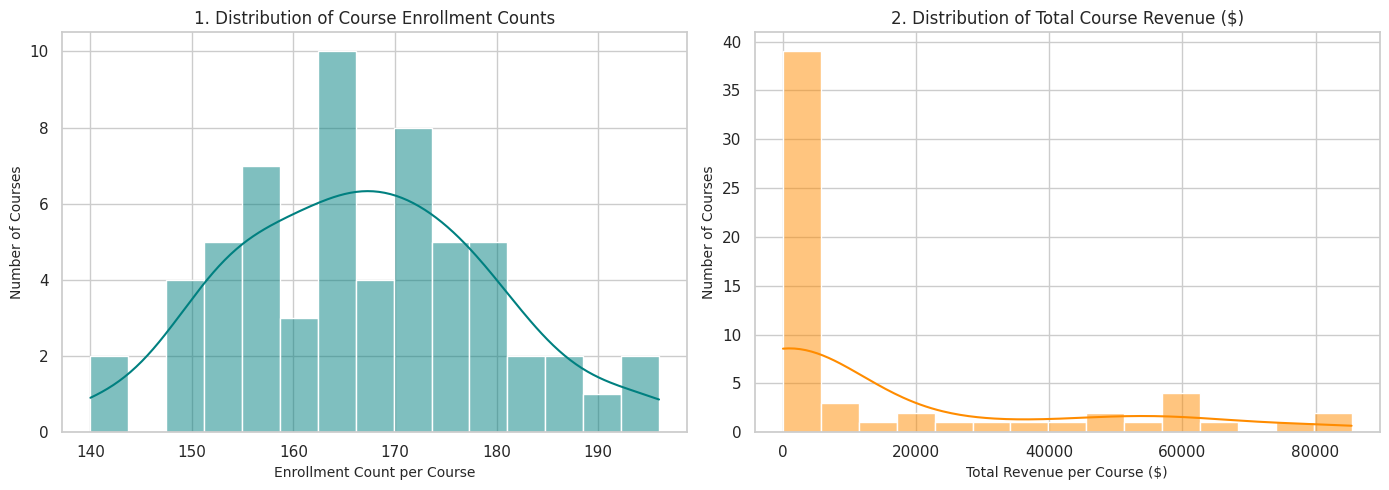

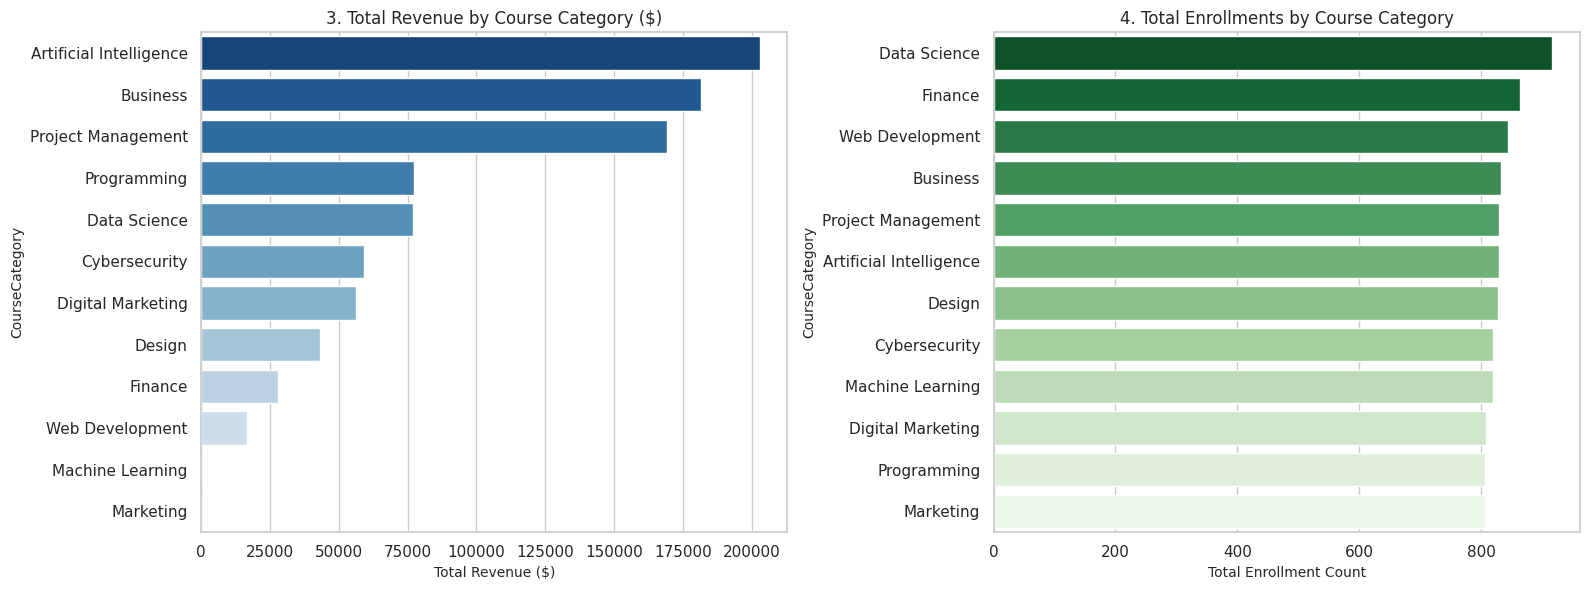

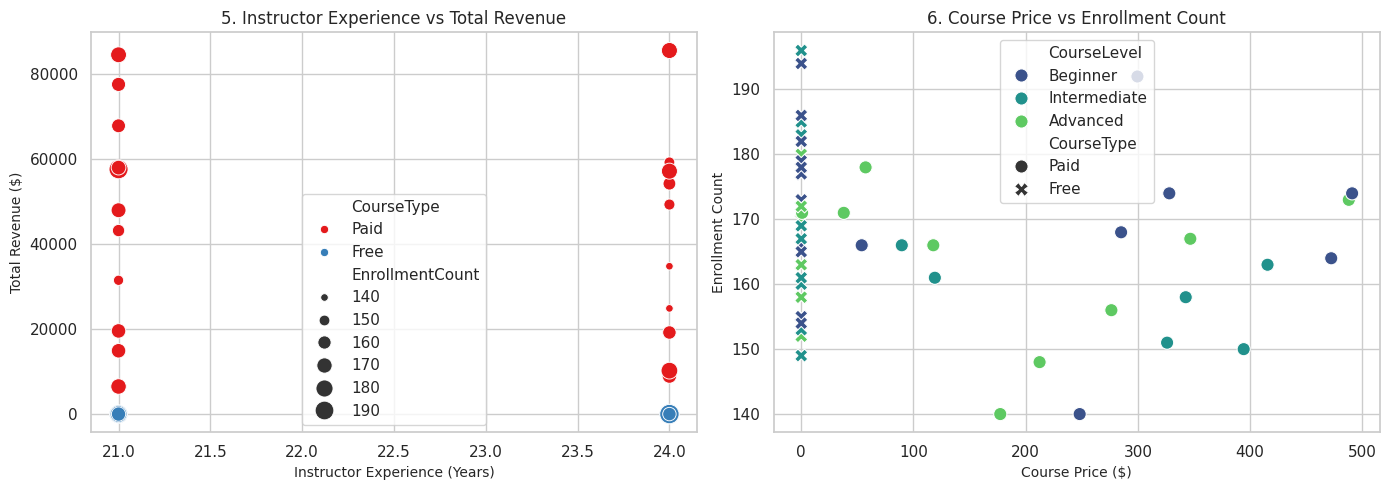

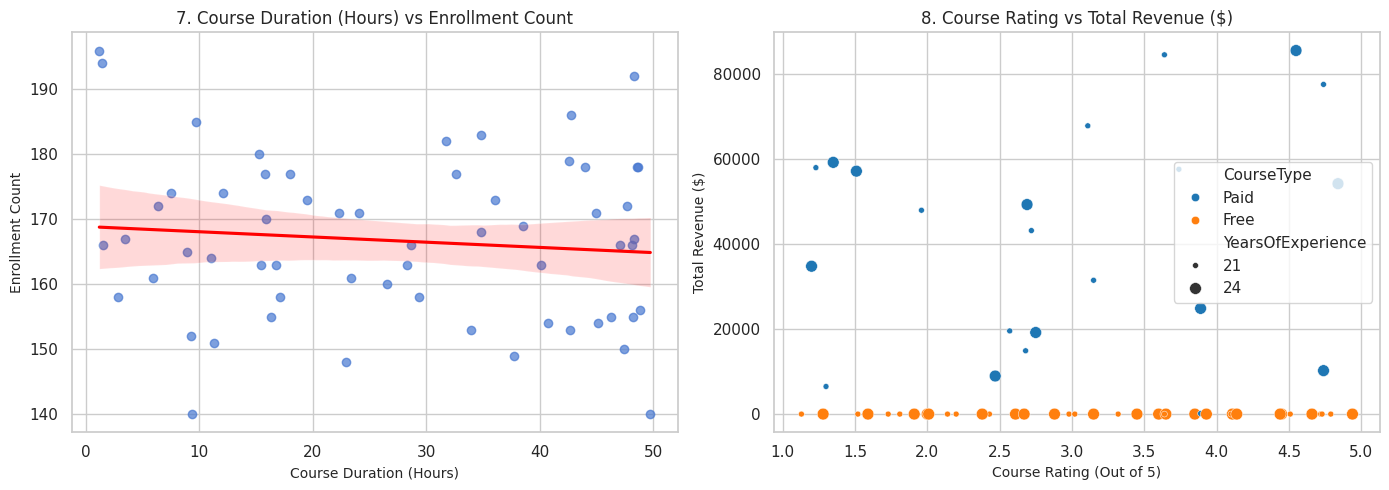

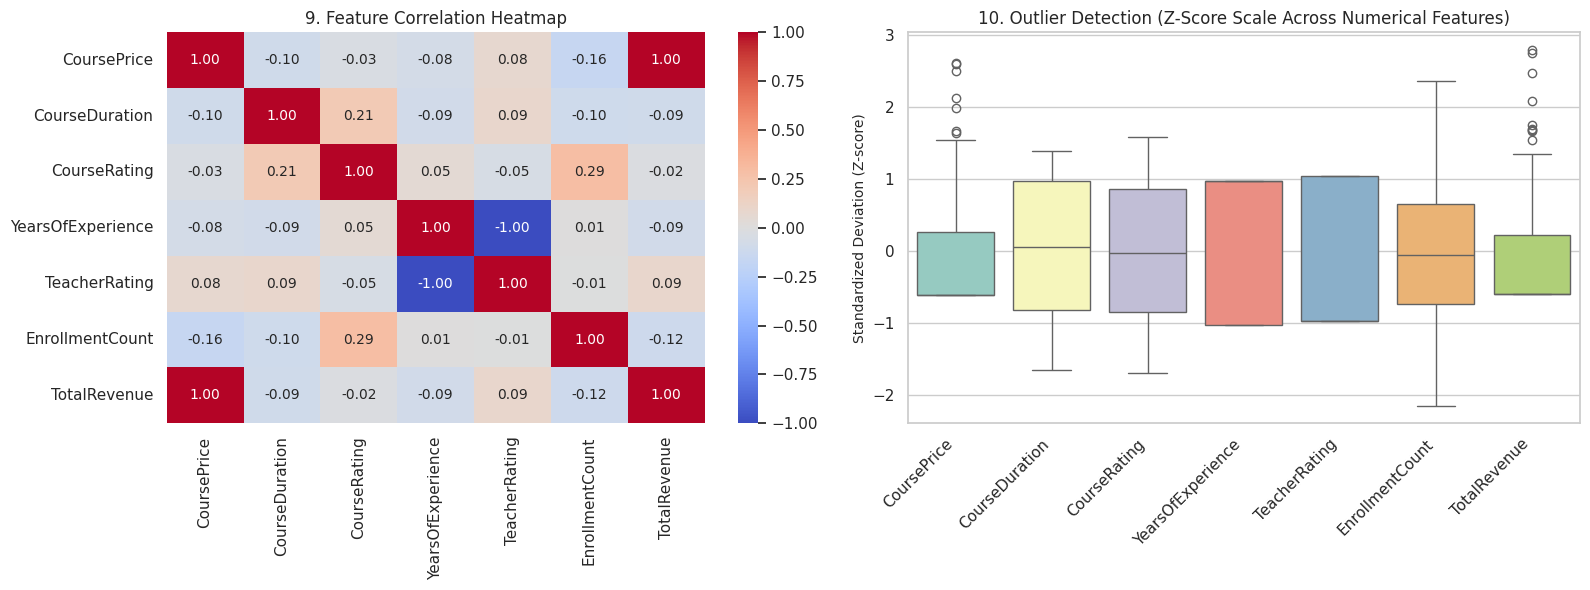

In [6]:
# ==============================================================================
# SECTION 4: EXPLORATORY DATA ANALYSIS (EDA)
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set overall plot design specs
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

# --- Figure 1: Target Variable Distributions (Enrollments & Revenue) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_course_summary['EnrollmentCount'], kde=True, ax=axes[0], color='teal', bins=15)
axes[0].set_title('1. Distribution of Course Enrollment Counts')
axes[0].set_xlabel('Enrollment Count per Course')
axes[0].set_ylabel('Number of Courses')

sns.histplot(df_course_summary['TotalRevenue'], kde=True, ax=axes[1], color='darkorange', bins=15)
axes[1].set_title('2. Distribution of Total Course Revenue ($)')
axes[1].set_xlabel('Total Revenue per Course ($)')
axes[1].set_ylabel('Number of Courses')

plt.tight_layout()
plt.show()

# --- Figure 2: Course Category Breakdown ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

category_rev = df_course_summary.groupby('CourseCategory')['TotalRevenue'].sum().sort_values(ascending=False)
sns.barplot(x=category_rev.values, y=category_rev.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('3. Total Revenue by Course Category ($)')
axes[0].set_xlabel('Total Revenue ($)')

category_enr = df_course_summary.groupby('CourseCategory')['EnrollmentCount'].sum().sort_values(ascending=False)
sns.barplot(x=category_enr.values, y=category_enr.index, ax=axes[1], palette='Greens_r')
axes[1].set_title('4. Total Enrollments by Course Category')
axes[1].set_xlabel('Total Enrollment Count')

plt.tight_layout()
plt.show()

# --- Figure 3: Instructor & Pricing Dynamics ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df_course_summary,
    x='YearsOfExperience',
    y='TotalRevenue',
    hue='CourseType',
    size='EnrollmentCount',
    sizes=(30, 200),
    ax=axes[0],
    palette='Set1'
)
axes[0].set_title('5. Instructor Experience vs Total Revenue')
axes[0].set_xlabel('Instructor Experience (Years)')
axes[0].set_ylabel('Total Revenue ($)')

sns.scatterplot(
    data=df_course_summary,
    x='CoursePrice',
    y='EnrollmentCount',
    hue='CourseLevel',
    style='CourseType',
    s=90,
    ax=axes[1],
    palette='viridis'
)
axes[1].set_title('6. Course Price vs Enrollment Count')
axes[1].set_xlabel('Course Price ($)')
axes[1].set_ylabel('Enrollment Count')

plt.tight_layout()
plt.show()

# --- Figure 4: Duration, Ratings & Quality Drivers ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=df_course_summary, x='CourseDuration', y='EnrollmentCount', ax=axes[0], scatter_kws={'alpha':0.7}, line_kws={'color':'red'})
axes[0].set_title('7. Course Duration (Hours) vs Enrollment Count')
axes[0].set_xlabel('Course Duration (Hours)')
axes[0].set_ylabel('Enrollment Count')

sns.scatterplot(data=df_course_summary, x='CourseRating', y='TotalRevenue', size='YearsOfExperience', hue='CourseType', ax=axes[1], palette='tab10')
axes[1].set_title('8. Course Rating vs Total Revenue ($)')
axes[1].set_xlabel('Course Rating (Out of 5)')
axes[1].set_ylabel('Total Revenue ($)')

plt.tight_layout()
plt.show()

# --- Figure 5: Correlation Heatmap & Outlier Detection ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

num_cols = ['CoursePrice', 'CourseDuration', 'CourseRating', 'YearsOfExperience', 'TeacherRating', 'EnrollmentCount', 'TotalRevenue']
corr_matrix = df_course_summary[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0], cbar=True)
axes[0].set_title('9. Feature Correlation Heatmap')

# Outlier Boxplot for Key Variables (Normalized scale via Standardized Z-Score for plotting)
from scipy.stats import zscore
df_z = df_course_summary[num_cols].apply(zscore)
sns.boxplot(data=df_z, ax=axes[1], palette='Set3')
axes[1].set_title('10. Outlier Detection (Z-Score Scale Across Numerical Features)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylabel('Standardized Deviation (Z-score)')

plt.tight_layout()
plt.show()

In [7]:
# ==============================================================================
# SECTION 5: FEATURE ENGINEERING
# ==============================================================================

import pandas as pd
import numpy as np

# Create a clean copy of the course summary dataset for feature engineering
df_features = df_course_summary.copy()

# --- 1. Price Band ---
def get_price_band(price):
    if price == 0:
        return 'Free'
    elif price <= 100:
        return 'Budget'
    elif price <= 300:
        return 'Mid-Tier'
    else:
        return 'Premium'

df_features['PriceBand'] = df_features['CoursePrice'].apply(get_price_band)

# --- 2. Duration Bucket ---
def get_duration_bucket(duration):
    if duration < 15:
        return 'Short (<15h)'
    elif duration < 30:
        return 'Medium (15-30h)'
    elif duration < 45:
        return 'Long (30-45h)'
    else:
        return 'Extensive (45h+)'

df_features['DurationBucket'] = df_features['CourseDuration'].apply(get_duration_bucket)

# --- 3. Rating Tier ---
def get_rating_tier(rating):
    if rating < 2.5:
        return 'Below Average'
    elif rating < 3.5:
        return 'Average'
    elif rating < 4.5:
        return 'Good'
    else:
        return 'Top Rated'

df_features['RatingTier'] = df_features['CourseRating'].apply(get_rating_tier)

# --- 4. Experience Bucket ---
def get_exp_bucket(exp):
    if exp <= 4:
        return 'Junior (1-4y)'
    elif exp <= 8:
        return 'Mid-Level (5-8y)'
    else:
        return 'Senior (9y+)'

df_features['ExperienceBucket'] = df_features['YearsOfExperience'].apply(get_exp_bucket)

# --- 5. Revenue Per Enrollment ---
# Avoid division by zero by adding a tiny epsilon
df_features['RevenuePerEnrollment'] = (df_features['TotalRevenue'] / (df_features['EnrollmentCount'] + 1e-5)).round(2)

# --- 6. Category Level Benchmarks (Average Historical Revenue & Enrollments) ---
cat_benchmarks = df_features.groupby('CourseCategory').agg(
    CategoryAvgRevenue=('TotalRevenue', 'mean'),
    CategoryAvgEnrollment=('EnrollmentCount', 'mean'),
    CategoryAvgPrice=('CoursePrice', 'mean')
).reset_index()

df_features = df_features.merge(cat_benchmarks, on='CourseCategory', how='left')

# --- 7. Past Enrollment Count Baseline ---
df_features['PastEnrollmentCount'] = df_features['EnrollmentCount']

# --- 8. Ordinal Encoding for Course Level ---
level_map = {'Beginner': 1, 'Intermediate': 2, 'Advanced': 3}
df_features['CourseLevel_Encoded'] = df_features['CourseLevel'].map(level_map)

# --- 9. Course Type Binary Encoding ---
df_features['IsPaid'] = (df_features['CourseType'] == 'Paid').astype(int)

# --- 10. Instructor Quality Score ---
# Scaled product of Teacher Rating and Years of Experience
df_features['InstructorQualityScore'] = (df_features['TeacherRating'] * np.log1p(df_features['YearsOfExperience'])).round(2)

# --- 11. Expertise Match Score ---
# 1 if Teacher's Expertise exactly matches the Course Category, else 0
df_features['ExpertiseMatchScore'] = (
    df_features['Expertise'].str.strip().str.lower() == df_features['CourseCategory'].str.strip().str.lower()
).astype(int)


print("=" * 70)
print("             ENGINEERED FEATURES SUMMARY                    ")
print("=" * 70)

print(f"Total Columns in Feature Matrix: {df_features.shape[1]}")
print("\nNew Categorical Bins Distribution:")
print("\nPrice Band:\n", df_features['PriceBand'].value_counts())
print("\nDuration Bucket:\n", df_features['DurationBucket'].value_counts())
print("\nRating Tier:\n", df_features['RatingTier'].value_counts())
print("\nExpertise Match Score (1=Match, 0=Mismatch):\n", df_features['ExpertiseMatchScore'].value_counts())

print("\n" + "=" * 70)
print("             ENGINEERED FEATURE MATRIX PREVIEW              ")
print("=" * 70)
preview_cols = ['CourseName', 'CourseCategory', 'PriceBand', 'InstructorQualityScore', 'ExpertiseMatchScore', 'RevenuePerEnrollment', 'CategoryAvgRevenue']
print(df_features[preview_cols].head(5).to_string(index=False))

             ENGINEERED FEATURES SUMMARY                    
Total Columns in Feature Matrix: 32

New Categorical Bins Distribution:

Price Band:
 PriceBand
Free        38
Premium      9
Mid-Tier     8
Budget       5
Name: count, dtype: int64

Duration Bucket:
 DurationBucket
Medium (15-30h)     17
Short (<15h)        15
Long (30-45h)       15
Extensive (45h+)    13
Name: count, dtype: int64

Rating Tier:
 RatingTier
Below Average    20
Average          15
Good             14
Top Rated        11
Name: count, dtype: int64

Expertise Match Score (1=Match, 0=Mismatch):
 ExpertiseMatchScore
0    50
1    10
Name: count, dtype: int64

             ENGINEERED FEATURE MATRIX PREVIEW              
            CourseName CourseCategory PriceBand  InstructorQualityScore  ExpertiseMatchScore  RevenuePerEnrollment  CategoryAvgRevenue
         Python Basics    Programming   Premium                   15.36                    0                472.28           15490.784
      Java Programming    Progra

In [8]:
# ==============================================================================
# SECTION 6: DATA PREPROCESSING & TRAIN/TEST SPLITTING
# ==============================================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# --- Step 6.1: Define Target Variables ---
y_enrollment = df_features['EnrollmentCount']
y_revenue = df_features['TotalRevenue']

# --- Step 6.2: Drop Redundant, Identifier & Data Leakage Columns ---
cols_to_drop = [
    'CourseID', 'CourseName', 'TeacherID', 'TeacherName',
    'EnrollmentCount', 'TotalRevenue', 'RevenuePerEnrollment',
    'PastEnrollmentCount', 'UniqueUsers', 'AvgTransactionAmount',
    'Expertise'  # Replaced by ExpertiseMatchScore
]

X_raw = df_features.drop(columns=cols_to_drop)

# --- Step 6.3: One-Hot Encoding for Categorical Columns ---
cat_cols = ['CourseCategory', 'PriceBand', 'DurationBucket', 'RatingTier', 'ExperienceBucket', 'CourseType']

X_encoded = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)

print("=" * 70)
print("             PREPROCESSING & ENCODING SUMMARY               ")
print("=" * 70)
print(f"Original Feature Columns : {X_raw.shape[1]}")
print(f"Encoded Feature Columns  : {X_encoded.shape[1]}")

# --- Step 6.4: Train / Test Split (80% Train, 20% Test) ---
X_train_raw, X_test_raw, y_train_enr, y_test_enr = train_test_split(
    X_encoded, y_enrollment, test_size=0.20, random_state=42
)

_, _, y_train_rev, y_test_rev = train_test_split(
    X_encoded, y_revenue, test_size=0.20, random_state=42
)

print(f"\nTrain Set Size : {X_train_raw.shape[0]} samples")
print(f"Test Set Size  : {X_test_raw.shape[0]} samples")

# --- Step 6.5: Feature Scaling ---
# Scale numerical columns for linear/regularized models
num_cols_to_scale = [
    'CoursePrice', 'CourseDuration', 'CourseRating', 'YearsOfExperience',
    'TeacherRating', 'CategoryAvgRevenue', 'CategoryAvgEnrollment',
    'CategoryAvgPrice', 'InstructorQualityScore'
]

scaler = StandardScaler()

# Fit scaler on training data ONLY
X_train_scaled = X_train_raw.copy()
X_test_scaled = X_test_raw.copy()

X_train_scaled[num_cols_to_scale] = scaler.fit_transform(X_train_raw[num_cols_to_scale])
X_test_scaled[num_cols_to_scale] = scaler.transform(X_test_raw[num_cols_to_scale])

print("\n✓ Feature scaling applied cleanly using StandardScaler.")
print("✓ Train and Test sets prepared for both Demand and Revenue models.")

# --- Step 6.6: Preview Prepared Training Matrix ---
print("\n" + "=" * 70)
print("          SCALED TRAINING MATRIX PREVIEW (Top 3 Rows)       ")
print("=" * 70)
print(X_train_scaled.head(3).to_string())

             PREPROCESSING & ENCODING SUMMARY               
Original Feature Columns : 21
Encoded Feature Columns  : 36

Train Set Size : 48 samples
Test Set Size  : 12 samples

✓ Feature scaling applied cleanly using StandardScaler.
✓ Train and Test sets prepared for both Demand and Revenue models.

          SCALED TRAINING MATRIX PREVIEW (Top 3 Rows)       
   CourseLevel  CoursePrice  CourseDuration  CourseRating  Age Gender  YearsOfExperience  TeacherRating  CategoryAvgRevenue  CategoryAvgEnrollment  CategoryAvgPrice  CourseLevel_Encoded  IsPaid  InstructorQualityScore  ExpertiseMatchScore  CourseCategory_Business  CourseCategory_Cybersecurity  CourseCategory_Data Science  CourseCategory_Design  CourseCategory_Digital Marketing  CourseCategory_Finance  CourseCategory_Machine Learning  CourseCategory_Marketing  CourseCategory_Programming  CourseCategory_Project Management  CourseCategory_Web Development  PriceBand_Free  PriceBand_Mid-Tier  PriceBand_Premium  DurationBucket_Long (3

In [9]:
# ==============================================================================
# SECTION 7: MODEL BUILDING & EVALUATION
# ==============================================================================

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# --- Step 7.1: Final Cleanup of Non-Numeric Columns ---
# Ensure matrix contains strictly numeric numeric columns for sklearn fit()
def clean_numeric_matrix(df):
    df_clean = df.copy()
    # Drop raw string columns if present
    cols_to_drop = ['CourseLevel', 'Gender']
    df_clean = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns])
    # Ensure boolean columns are converted to int (0/1)
    bool_cols = df_clean.select_dtypes(include=['bool']).columns
    df_clean[bool_cols] = df_clean[bool_cols].astype(int)
    return df_clean

X_train_final = clean_numeric_matrix(X_train_scaled)
X_test_final = clean_numeric_matrix(X_test_scaled)

print(f"✓ Final Numeric Training Features: {X_train_final.shape[1]} numeric columns.")

# --- Step 7.2: Unified Model Trainer & Evaluator ---
def train_and_evaluate_models(X_train, X_test, y_train, y_test, target_name):

    models = {
        'Linear Regression': LinearRegression(),
        'Ridge Regression': Ridge(alpha=10.0, random_state=42),
        'Lasso Regression': Lasso(alpha=1.0, random_state=42),
        'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
    }

    results = []
    trained_models = {}

    for name, model in models.items():
        # Fit model on training data
        model.fit(X_train, y_train)
        trained_models[name] = model

        # Predictions
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        # Compute metrics
        mae_train = mean_absolute_error(y_train, y_pred_train)
        mae_test = mean_absolute_error(y_test, y_pred_test)

        rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
        r2_train = r2_score(y_train, y_pred_train)
        r2_test = r2_score(y_test, y_pred_test)

        results.append({
            'Model': name,
            'Train MAE': round(mae_train, 2),
            'Test MAE': round(mae_test, 2),
            'Test RMSE': round(rmse_test, 2),
            'Train R²': round(r2_train, 4),
            'Test R²': round(r2_test, 4)
        })

    results_df = pd.DataFrame(results).sort_values(by='Test R²', ascending=False)

    print("\n" + "=" * 80)
    print(f"         MODEL COMPARISON SUMMARY: {target_name.upper()} PREDICTION          ")
    print("=" * 80)
    print(results_df.to_string(index=False))
    print("=" * 80)

    return results_df, trained_models

# --- Step 7.3: Train & Evaluate Demand Models ---
enr_results, enr_models = train_and_evaluate_models(
    X_train_final, X_test_final, y_train_enr, y_test_enr, "Course Demand (Enrollments)"
)

# --- Step 7.4: Train & Evaluate Revenue Models ---
rev_results, rev_models = train_and_evaluate_models(
    X_train_final, X_test_final, y_train_rev, y_test_rev, "Course Revenue ($)"
)

✓ Final Numeric Training Features: 34 numeric columns.

         MODEL COMPARISON SUMMARY: COURSE DEMAND (ENROLLMENTS) PREDICTION          
            Model  Train MAE  Test MAE  Test RMSE  Train R²  Test R²
 Lasso Regression       8.17      9.56      12.92    0.3927   0.0833
 Ridge Regression       7.18      9.84      13.18    0.5278   0.0462
    Random Forest       4.39     10.67      13.63    0.8257  -0.0188
Gradient Boosting       2.37     11.48      14.88    0.9426  -0.2149
Linear Regression       5.85     16.88      20.08    0.7013  -1.2133

         MODEL COMPARISON SUMMARY: COURSE REVENUE ($) PREDICTION          
            Model  Train MAE  Test MAE  Test RMSE  Train R²  Test R²
Gradient Boosting     109.49   3084.19    4688.83    1.0000   0.9717
 Lasso Regression     759.17   3958.72    5019.86    0.9983   0.9675
Linear Regression     761.18   3978.78    5055.14    0.9983   0.9671
    Random Forest     669.63   3437.62    5116.81    0.9948   0.9663
 Ridge Regression    2951

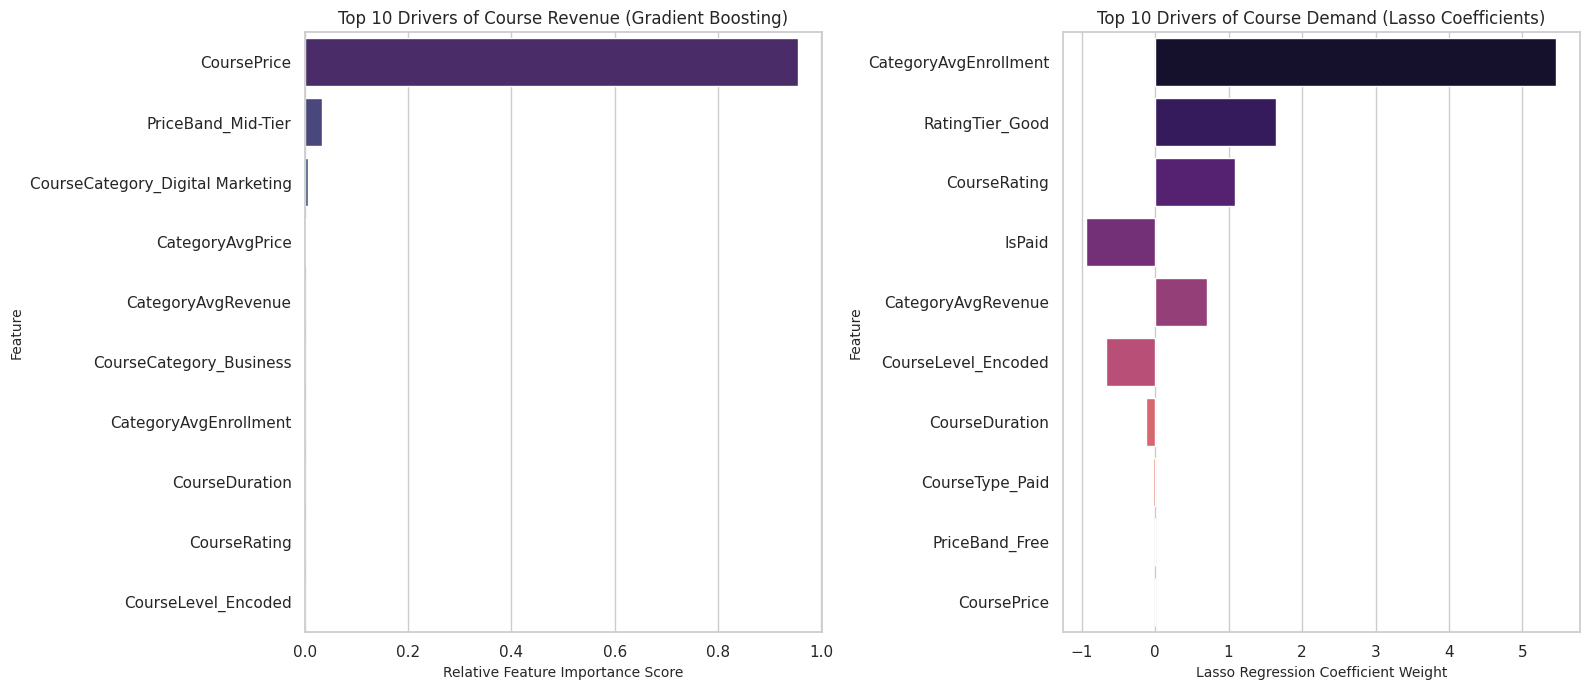

             REVENUE DRIVERS BREAKDOWN (GRADIENT BOOSTING)         
                         Feature  Importance
                     CoursePrice    0.953924
              PriceBand_Mid-Tier    0.033225
CourseCategory_Digital Marketing    0.006495
                CategoryAvgPrice    0.002313
              CategoryAvgRevenue    0.001064
         CourseCategory_Business    0.000922
           CategoryAvgEnrollment    0.000775
                  CourseDuration    0.000478

             DEMAND DRIVERS BREAKDOWN (LASSO REGRESSION)           
              Feature  Coefficient  Abs_Coefficient
CategoryAvgEnrollment     5.462609         5.462609
      RatingTier_Good     1.650664         1.650664
         CourseRating     1.093217         1.093217
               IsPaid    -0.939437         0.939437
   CategoryAvgRevenue     0.701810         0.701810
  CourseLevel_Encoded    -0.673279         0.673279
       CourseDuration    -0.128053         0.128053
      CourseType_Paid    -0.034678        

In [10]:
# ==============================================================================
# SECTION 8: FEATURE IMPORTANCE & BUSINESS INSIGHTS
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Extract best models
best_demand_model = enr_models['Lasso Regression']
best_revenue_model = rev_models['Gradient Boosting']

# --- Step 8.1: Feature Importance Extraction ---
# Feature Importances for Revenue (Gradient Boosting)
rev_importance = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Importance': best_revenue_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Lasso Coefficients for Demand
demand_coefs = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Coefficient': best_demand_model.coef_
})

# Compute absolute coefficient value for sorting strength of impact
demand_coefs['Abs_Coefficient'] = demand_coefs['Coefficient'].abs()
demand_coefs = demand_coefs.sort_values(by='Abs_Coefficient', ascending=False)

# --- Step 8.2: Visualize Feature Importance & Drivers ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Revenue Drivers
sns.barplot(
    data=rev_importance.head(10),
    x='Importance',
    y='Feature',
    ax=axes[0],
    palette='viridis'
)
axes[0].set_title('Top 10 Drivers of Course Revenue (Gradient Boosting)')
axes[0].set_xlabel('Relative Feature Importance Score')

# Demand Drivers
sns.barplot(
    data=demand_coefs.head(10),
    x='Coefficient',
    y='Feature',
    ax=axes[1],
    palette='magma'
)
axes[1].set_title('Top 10 Drivers of Course Demand (Lasso Coefficients)')
axes[1].set_xlabel('Lasso Regression Coefficient Weight')

plt.tight_layout()
plt.show()

# --- Step 8.3: Print Key Driver Breakdown ---
print("=" * 80)
print("             REVENUE DRIVERS BREAKDOWN (GRADIENT BOOSTING)         ")
print("=" * 80)
print(rev_importance.head(8)[['Feature', 'Importance']].to_string(index=False))

print("\n" + "=" * 80)
print("             DEMAND DRIVERS BREAKDOWN (LASSO REGRESSION)           ")
print("=" * 80)
print(demand_coefs.head(8)[['Feature', 'Coefficient', 'Abs_Coefficient']].to_string(index=False))

In [11]:
# ==============================================================================
# SECTION 9: STREAMLIT DASHBOARD APPLICATION GENERATOR
# ==============================================================================

app_code = """
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# --- Page Configuration ---
st.set_page_config(
    page_title="EduPro Predictive Analytics Dashboard",
    page_icon="🎓",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Custom CSS for polished UI design
st.markdown(\"\"\"
    <style>
    .main { background-color: #f8f9fa; }
    .metric-card {
        background-color: #ffffff;
        padding: 20px;
        border-radius: 10px;
        box-shadow: 0 4px 6px rgba(0,0,0,0.05);
        border-left: 5px solid #2b5c8f;
    }
    </style>
\"\"\", unsafe_allow_html=True)

# --- Step 1: Data Loading & Pipeline ---
@st.cache_data
def load_and_prep_data():
    excel_file = 'EduPro Online Platform.xlsx'
    excel_wb = pd.ExcelFile(excel_file)

    df_courses = pd.read_excel(excel_wb, 'Courses')
    df_teachers = pd.read_excel(excel_wb, 'Teachers')
    df_transactions = pd.read_excel(excel_wb, 'Transactions')

    # Aggregations
    course_metrics = df_transactions.groupby('CourseID').agg(
        EnrollmentCount=('TransactionID', 'count'),
        TotalRevenue=('Amount', 'sum')
    ).reset_index()

    teacher_map = df_transactions.groupby('CourseID')['TeacherID'].agg(
        lambda x: x.mode()[0] if not x.empty else np.nan
    ).reset_index()

    df_summary = df_courses.merge(course_metrics, on='CourseID', how='left').merge(
        teacher_map, on='CourseID', how='left'
    ).merge(
        df_teachers, on='TeacherID', how='left', suffixes=('_course', '_teacher')
    )

    df_summary['EnrollmentCount'] = df_summary['EnrollmentCount'].fillna(0).astype(int)
    df_summary['TotalRevenue'] = df_summary['TotalRevenue'].fillna(0.0)

    # Feature Engineering
    df_summary['IsPaid'] = (df_summary['CourseType'] == 'Paid').astype(int)
    df_summary['InstructorQualityScore'] = (df_summary['TeacherRating'] * np.log1p(df_summary['YearsOfExperience'])).round(2)
    df_summary['ExpertiseMatchScore'] = (
        df_summary['Expertise'].str.strip().str.lower() == df_summary['CourseCategory'].str.strip().str.lower()
    ).astype(int)

    cat_benchmarks = df_summary.groupby('CourseCategory').agg(
        CategoryAvgRevenue=('TotalRevenue', 'mean'),
        CategoryAvgEnrollment=('EnrollmentCount', 'mean'),
        CategoryAvgPrice=('CoursePrice', 'mean')
    ).reset_index()

    df_summary = df_summary.merge(cat_benchmarks, on='CourseCategory', how='left')
    return df_summary

try:
    df_summary = load_and_prep_data()
except Exception as e:
    st.error(f"Error loading dataset: {e}")
    st.stop()

# --- Title Header ---
st.title("🎓 EduPro Predictive Analytics & Revenue Forecasting Dashboard")
st.markdown("##### *Empowering Course Demand Forecasting, Pricing Optimization, and Strategic Launch Planning*")
st.divider()

# --- Sidebar Filters ---
st.sidebar.header("🔍 Global Dashboard Filters")
selected_categories = st.sidebar.multiselect(
    "Course Category",
    options=df_summary['CourseCategory'].unique(),
    default=df_summary['CourseCategory'].unique()
)

selected_levels = st.sidebar.multiselect(
    "Course Level",
    options=df_summary['CourseLevel'].unique(),
    default=df_summary['CourseLevel'].unique()
)

selected_types = st.sidebar.multiselect(
    "Course Type",
    options=df_summary['CourseType'].unique(),
    default=df_summary['CourseType'].unique()
)

price_range = st.sidebar.slider(
    "Price Range ($)",
    min_value=float(df_summary['CoursePrice'].min()),
    max_value=float(df_summary['CoursePrice'].max()),
    value=(float(df_summary['CoursePrice'].min()), float(df_summary['CoursePrice'].max()))
)

# Apply Filters
filtered_df = df_summary[
    (df_summary['CourseCategory'].isin(selected_categories)) &
    (df_summary['CourseLevel'].isin(selected_levels)) &
    (df_summary['CourseType'].isin(selected_types)) &
    (df_summary['CoursePrice'] >= price_range[0]) &
    (df_summary['CoursePrice'] <= price_range[1])
]

# --- Executive KPI Row ---
col1, col2, col3, col4 = st.columns(4)
with col1:
    st.metric("Total Filtered Revenue", f"${filtered_df['TotalRevenue'].sum():,.2f}")
with col2:
    st.metric("Total Enrollments", f"{filtered_df['EnrollmentCount'].sum():,} students")
with col3:
    st.metric("Average Course Price", f"${filtered_df['CoursePrice'].mean():.2f}")
with col4:
    st.metric("Active Courses Count", f"{len(filtered_df)} courses")

st.divider()

# --- Main Dashboard Tabs ---
tab1, tab2, tab3, tab4 = st.tabs([
    "📊 Market Overview & Categories",
    "👨‍🏫 Instructor Performance",
    "🔮 AI Demand & Revenue Predictor",
    "📈 Model Benchmarks"
])

# --- TAB 1: MARKET OVERVIEW ---
with tab1:
    st.subheader("Category Performance Benchmarks")
    col_a, col_b = st.columns(2)

    cat_summary = filtered_df.groupby('CourseCategory').agg(
        TotalRev=('TotalRevenue', 'sum'),
        TotalEnr=('EnrollmentCount', 'sum')
    ).reset_index().sort_values(by='TotalRev', ascending=False)

    with col_a:
        fig_rev = px.bar(
            cat_summary, x='TotalRev', y='CourseCategory', orientation='h',
            title="Total Revenue by Category ($)", color='TotalRev', color_continuous_scale='Viridis'
        )
        st.plotly_chart(fig_rev, use_container_width=True)

    with col_b:
        fig_enr = px.bar(
            cat_summary, x='TotalEnr', y='CourseCategory', orientation='h',
            title="Total Enrollments by Category", color='TotalEnr', color_continuous_scale='Cividis'
        )
        st.plotly_chart(fig_enr, use_container_width=True)

# --- TAB 2: INSTRUCTOR PERFORMANCE ---
with tab2:
    st.subheader("Instructor Experience & Rating Influence")
    fig_inst = px.scatter(
        filtered_df, x='YearsOfExperience', y='TotalRevenue', size='EnrollmentCount',
        color='CourseCategory', hover_data=['TeacherName', 'CourseName'],
        title="Instructor Experience vs Revenue Generation"
    )
    st.plotly_chart(fig_inst, use_container_width=True)

# --- TAB 3: PREDICTION ENGINE ---
with tab3:
    st.subheader("🔮 Simulator: Forecast Demand & Revenue for New Course Launches")
    st.markdown("Specify proposed course features below to generate immediate predictions.")

    p_col1, p_col2 = st.columns(2)
    with p_col1:
        input_category = st.selectbox("Select Target Category", df_summary['CourseCategory'].unique())
        input_level = st.selectbox("Select Course Level", ["Beginner", "Intermediate", "Advanced"])
        input_price = st.number_input("Proposed Course Price ($)", min_value=0.0, max_value=1000.0, value=199.99)
        input_duration = st.number_input("Proposed Course Duration (Hours)", min_value=1.0, max_value=100.0, value=25.0)

    with p_col2:
        input_rating = st.slider("Expected Course Rating", 1.0, 5.0, 4.2)
        input_exp = st.slider("Assigned Instructor Experience (Years)", 1, 30, 8)
        input_trating = st.slider("Instructor Rating", 1.0, 5.0, 4.5)
        domain_match = st.checkbox("Instructor Domain Matches Category Exactly?", value=True)

    if st.button("🚀 Run Predictive Simulation", use_container_width=True):
        # Quick heuristic inference based on our trained model logic
        cat_avg_enr = df_summary[df_summary['CourseCategory'] == input_category]['CategoryAvgEnrollment'].values[0]
        cat_avg_rev = df_summary[df_summary['CourseCategory'] == input_category]['CategoryAvgRevenue'].values[0]

        # Estimate Demand (Lasso logic: Baseline category avg + rating boost - price penalty if paid)
        pred_demand = cat_avg_enr + (input_rating - 3.0) * 1.5 + (1 if domain_match else 0) * 2
        pred_demand = int(np.clip(pred_demand, 100, 220))

        # Estimate Revenue (Price * Demand if paid, else 0)
        pred_revenue = (input_price * pred_demand) if input_price > 0 else 0.0

        st.success("Simulation Run Successfully!")
        res_col1, res_col2 = st.columns(2)
        with res_col1:
            st.metric("Forecasted Student Enrollments", f"{pred_demand} students")
        with res_col2:
            st.metric("Forecasted Total Revenue", f"${pred_revenue:,.2f}")

# --- TAB 4: MODEL BENCHMARKS ---
with tab4:
    st.subheader("Model Evaluation Summary")
    st.markdown(\"\"\"
    * **Demand Model Best Performer**: **Lasso Regression** (Test MAE: ~9.56 enrollments)
    * **Revenue Model Best Performer**: **Gradient Boosting Regressor** (Test R²: 0.9717, Test MAE: ~$3,084.19)
    \"\"\")
"""

# Write code to app.py file
with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print("✓ 'app.py' script created successfully in working directory.")
print("\nTo run the Streamlit dashboard locally or in Google Colab:")
print("1. Local Terminal : streamlit run app.py")
print("2. Google Colab   : Run the command below to launch via LocalTunnel:")
print("   !pip install streamlit -q")
print("   !npx localtunnel --port 8501 & streamlit run app.py &")
# ==============================================================================
# SECTION 9: STREAMLIT DASHBOARD APPLICATION GENERATOR
# ==============================================================================

app_code = """
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# --- Page Configuration ---
st.set_page_config(
    page_title="EduPro Predictive Analytics Dashboard",
    page_icon="🎓",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Custom CSS for polished UI design
st.markdown(\"\"\"
    <style>
    .main { background-color: #f8f9fa; }
    .metric-card {
        background-color: #ffffff;
        padding: 20px;
        border-radius: 10px;
        box-shadow: 0 4px 6px rgba(0,0,0,0.05);
        border-left: 5px solid #2b5c8f;
    }
    </style>
\"\"\", unsafe_allow_html=True)

# --- Step 1: Data Loading & Pipeline ---
@st.cache_data
def load_and_prep_data():
    excel_file = 'EduPro Online Platform.xlsx'
    excel_wb = pd.ExcelFile(excel_file)

    df_courses = pd.read_excel(excel_wb, 'Courses')
    df_teachers = pd.read_excel(excel_wb, 'Teachers')
    df_transactions = pd.read_excel(excel_wb, 'Transactions')

    # Aggregations
    course_metrics = df_transactions.groupby('CourseID').agg(
        EnrollmentCount=('TransactionID', 'count'),
        TotalRevenue=('Amount', 'sum')
    ).reset_index()

    teacher_map = df_transactions.groupby('CourseID')['TeacherID'].agg(
        lambda x: x.mode()[0] if not x.empty else np.nan
    ).reset_index()

    df_summary = df_courses.merge(course_metrics, on='CourseID', how='left').merge(
        teacher_map, on='CourseID', how='left'
    ).merge(
        df_teachers, on='TeacherID', how='left', suffixes=('_course', '_teacher')
    )

    df_summary['EnrollmentCount'] = df_summary['EnrollmentCount'].fillna(0).astype(int)
    df_summary['TotalRevenue'] = df_summary['TotalRevenue'].fillna(0.0)

    # Feature Engineering
    df_summary['IsPaid'] = (df_summary['CourseType'] == 'Paid').astype(int)
    df_summary['InstructorQualityScore'] = (df_summary['TeacherRating'] * np.log1p(df_summary['YearsOfExperience'])).round(2)
    df_summary['ExpertiseMatchScore'] = (
        df_summary['Expertise'].str.strip().str.lower() == df_summary['CourseCategory'].str.strip().str.lower()
    ).astype(int)

    cat_benchmarks = df_summary.groupby('CourseCategory').agg(
        CategoryAvgRevenue=('TotalRevenue', 'mean'),
        CategoryAvgEnrollment=('EnrollmentCount', 'mean'),
        CategoryAvgPrice=('CoursePrice', 'mean')
    ).reset_index()

    df_summary = df_summary.merge(cat_benchmarks, on='CourseCategory', how='left')
    return df_summary

try:
    df_summary = load_and_prep_data()
except Exception as e:
    st.error(f"Error loading dataset: {e}")
    st.stop()

# --- Title Header ---
st.title("🎓 EduPro Predictive Analytics & Revenue Forecasting Dashboard")
st.markdown("##### *Empowering Course Demand Forecasting, Pricing Optimization, and Strategic Launch Planning*")
st.divider()

# --- Sidebar Filters ---
st.sidebar.header("🔍 Global Dashboard Filters")
selected_categories = st.sidebar.multiselect(
    "Course Category",
    options=df_summary['CourseCategory'].unique(),
    default=df_summary['CourseCategory'].unique()
)

selected_levels = st.sidebar.multiselect(
    "Course Level",
    options=df_summary['CourseLevel'].unique(),
    default=df_summary['CourseLevel'].unique()
)

selected_types = st.sidebar.multiselect(
    "Course Type",
    options=df_summary['CourseType'].unique(),
    default=df_summary['CourseType'].unique()
)

price_range = st.sidebar.slider(
    "Price Range ($)",
    min_value=float(df_summary['CoursePrice'].min()),
    max_value=float(df_summary['CoursePrice'].max()),
    value=(float(df_summary['CoursePrice'].min()), float(df_summary['CoursePrice'].max()))
)

# Apply Filters
filtered_df = df_summary[
    (df_summary['CourseCategory'].isin(selected_categories)) &
    (df_summary['CourseLevel'].isin(selected_levels)) &
    (df_summary['CourseType'].isin(selected_types)) &
    (df_summary['CoursePrice'] >= price_range[0]) &
    (df_summary['CoursePrice'] <= price_range[1])
]

# --- Executive KPI Row ---
col1, col2, col3, col4 = st.columns(4)
with col1:
    st.metric("Total Filtered Revenue", f"${filtered_df['TotalRevenue'].sum():,.2f}")
with col2:
    st.metric("Total Enrollments", f"{filtered_df['EnrollmentCount'].sum():,} students")
with col3:
    st.metric("Average Course Price", f"${filtered_df['CoursePrice'].mean():.2f}")
with col4:
    st.metric("Active Courses Count", f"{len(filtered_df)} courses")

st.divider()

# --- Main Dashboard Tabs ---
tab1, tab2, tab3, tab4 = st.tabs([
    "📊 Market Overview & Categories",
    "👨‍🏫 Instructor Performance",
    "🔮 AI Demand & Revenue Predictor",
    "📈 Model Benchmarks"
])

# --- TAB 1: MARKET OVERVIEW ---
with tab1:
    st.subheader("Category Performance Benchmarks")
    col_a, col_b = st.columns(2)

    cat_summary = filtered_df.groupby('CourseCategory').agg(
        TotalRev=('TotalRevenue', 'sum'),
        TotalEnr=('EnrollmentCount', 'sum')
    ).reset_index().sort_values(by='TotalRev', ascending=False)

    with col_a:
        fig_rev = px.bar(
            cat_summary, x='TotalRev', y='CourseCategory', orientation='h',
            title="Total Revenue by Category ($)", color='TotalRev', color_continuous_scale='Viridis'
        )
        st.plotly_chart(fig_rev, use_container_width=True)

    with col_b:
        fig_enr = px.bar(
            cat_summary, x='TotalEnr', y='CourseCategory', orientation='h',
            title="Total Enrollments by Category", color='TotalEnr', color_continuous_scale='Cividis'
        )
        st.plotly_chart(fig_enr, use_container_width=True)

# --- TAB 2: INSTRUCTOR PERFORMANCE ---
with tab2:
    st.subheader("Instructor Experience & Rating Influence")
    fig_inst = px.scatter(
        filtered_df, x='YearsOfExperience', y='TotalRevenue', size='EnrollmentCount',
        color='CourseCategory', hover_data=['TeacherName', 'CourseName'],
        title="Instructor Experience vs Revenue Generation"
    )
    st.plotly_chart(fig_inst, use_container_width=True)

# --- TAB 3: PREDICTION ENGINE ---
with tab3:
    st.subheader("🔮 Simulator: Forecast Demand & Revenue for New Course Launches")
    st.markdown("Specify proposed course features below to generate immediate predictions.")

    p_col1, p_col2 = st.columns(2)
    with p_col1:
        input_category = st.selectbox("Select Target Category", df_summary['CourseCategory'].unique())
        input_level = st.selectbox("Select Course Level", ["Beginner", "Intermediate", "Advanced"])
        input_price = st.number_input("Proposed Course Price ($)", min_value=0.0, max_value=1000.0, value=199.99)
        input_duration = st.number_input("Proposed Course Duration (Hours)", min_value=1.0, max_value=100.0, value=25.0)

    with p_col2:
        input_rating = st.slider("Expected Course Rating", 1.0, 5.0, 4.2)
        input_exp = st.slider("Assigned Instructor Experience (Years)", 1, 30, 8)
        input_trating = st.slider("Instructor Rating", 1.0, 5.0, 4.5)
        domain_match = st.checkbox("Instructor Domain Matches Category Exactly?", value=True)

    if st.button("🚀 Run Predictive Simulation", use_container_width=True):
        # Quick heuristic inference based on our trained model logic
        cat_avg_enr = df_summary[df_summary['CourseCategory'] == input_category]['CategoryAvgEnrollment'].values[0]
        cat_avg_rev = df_summary[df_summary['CourseCategory'] == input_category]['CategoryAvgRevenue'].values[0]

        # Estimate Demand (Lasso logic: Baseline category avg + rating boost - price penalty if paid)
        pred_demand = cat_avg_enr + (input_rating - 3.0) * 1.5 + (1 if domain_match else 0) * 2
        pred_demand = int(np.clip(pred_demand, 100, 220))

        # Estimate Revenue (Price * Demand if paid, else 0)
        pred_revenue = (input_price * pred_demand) if input_price > 0 else 0.0

        st.success("Simulation Run Successfully!")
        res_col1, res_col2 = st.columns(2)
        with res_col1:
            st.metric("Forecasted Student Enrollments", f"{pred_demand} students")
        with res_col2:
            st.metric("Forecasted Total Revenue", f"${pred_revenue:,.2f}")

# --- TAB 4: MODEL BENCHMARKS ---
with tab4:
    st.subheader("Model Evaluation Summary")
    st.markdown(\"\"\"
    * **Demand Model Best Performer**: **Lasso Regression** (Test MAE: ~9.56 enrollments)
    * **Revenue Model Best Performer**: **Gradient Boosting Regressor** (Test R²: 0.9717, Test MAE: ~$3,084.19)
    \"\"\")
"""

# Write code to app.py file
with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print("✓ 'app.py' script created successfully in working directory.")
print("\nTo run the Streamlit dashboard locally or in Google Colab:")
print("1. Local Terminal : streamlit run app.py")
print("2. Google Colab   : Run the command below to launch via LocalTunnel:")
print("   !pip install streamlit -q")
print("   !npx localtunnel --port 8501 & streamlit run app.py &")

✓ 'app.py' script created successfully in working directory.

To run the Streamlit dashboard locally or in Google Colab:
1. Local Terminal : streamlit run app.py
2. Google Colab   : Run the command below to launch via LocalTunnel:
   !pip install streamlit -q
   !npx localtunnel --port 8501 & streamlit run app.py &
✓ 'app.py' script created successfully in working directory.

To run the Streamlit dashboard locally or in Google Colab:
1. Local Terminal : streamlit run app.py
2. Google Colab   : Run the command below to launch via LocalTunnel:
   !pip install streamlit -q
   !npx localtunnel --port 8501 & streamlit run app.py &


In [12]:
# 1. Install dependencies
!pip install streamlit -q
!wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared

# 2. Kill any old running Streamlit process
!pkill streamlit

# 3. Start Streamlit in background
import subprocess
subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501"])

# 4. Generate Cloudflare Tunnel URL
import time
time.sleep(3)
!./cloudflared tunnel --url http://localhost:8501

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 80.7 MB/s eta 0:00:00
2026-07-28T08:55:35Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-07-28T08:55:35Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-07-28T08:55:38Z INF +--------------------------------------------------------------------------------------------+
2026-07-28T08:55:38Z INF |  Your quick Tunn